# Shoreline Detection using K-means

## Method overview (add diagram)

## Data grouping

In [8]:
from datetime import datetime

folder = "data\\Planet_data_EPSG28992\\"

summer_months = [
    "2025-06-19_strip_8141392_composite.tif",
    "2024-06-23_strip_7392265_composite.tif",
    "2023-06-15_strip_6579851_composite.tif",
    #"2022-10-09_strip_5992163_composite.tif",
    "2022-06-21_strip_5728503_composite.tif",
    "2021-06-27_strip_4630194_composite.tif",
    "2020-06-24_strip_3512625_composite.tif",
    "2019-06-14_strip_2443911_composite.tif",
    "2018-06-29_strip_1532242_composite.tif",
    "2017-07-06_strip_602670_composite.tif"
]

winter_months = [
    "2025-02-26_strip_7892478_composite.tif",
    "2024-10-05_strip_7618271_composite.tif",
    "2020-10-23_strip_3833704_composite.tif",
    "2020-02-07_strip_3113467_composite.tif",
    "2019-10-16_strip_2755420_composite.tif",
    "2019-02-15_strip_2122432_composite.tif",
    "2018-10-05_strip_1746499_composite.tif",
    "2018-02-22_strip_1201956_composite.tif",
    "2017-10-15_strip_838927_composite.tif"
]

# Sort lists by the leading YYYY-MM-DD date (ascending)
def _sort_by_date(lst):
    return sorted(lst, key=lambda s: datetime.strptime(s[:10], "%Y-%m-%d"))

summer_months = _sort_by_date(summer_months)
winter_months = _sort_by_date(winter_months)

In [9]:
# print elements in summer_months and file sizes
import os
for fname in summer_months:
    fpath = os.path.join(folder, fname)
    if os.path.exists(fpath):
        fsize = os.path.getsize(fpath) / (1024 * 1024)
        print(f"{fname}: {fsize:.2f} MB")
    else:
        print(f"{fname}: file not found")

2017-07-06_strip_602670_composite.tif: 27.22 MB
2018-06-29_strip_1532242_composite.tif: 27.22 MB
2019-06-14_strip_2443911_composite.tif: 27.22 MB
2020-06-24_strip_3512625_composite.tif: 27.22 MB
2021-06-27_strip_4630194_composite.tif: 27.22 MB
2022-06-21_strip_5728503_composite.tif: 27.22 MB
2023-06-15_strip_6579851_composite.tif: 27.22 MB
2024-06-23_strip_7392265_composite.tif: 27.22 MB
2025-06-19_strip_8141392_composite.tif: 27.22 MB


## Image processing

File: 2017-07-06_strip_602670_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2018-06-29_strip_1532242_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2019-06-14_strip_2443911_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2020-06-24_strip_3512625_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2021-06-27_strip_4630194_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2022-06-21_strip_5728503_composite.tif
Shape: (4, 1966, 1814

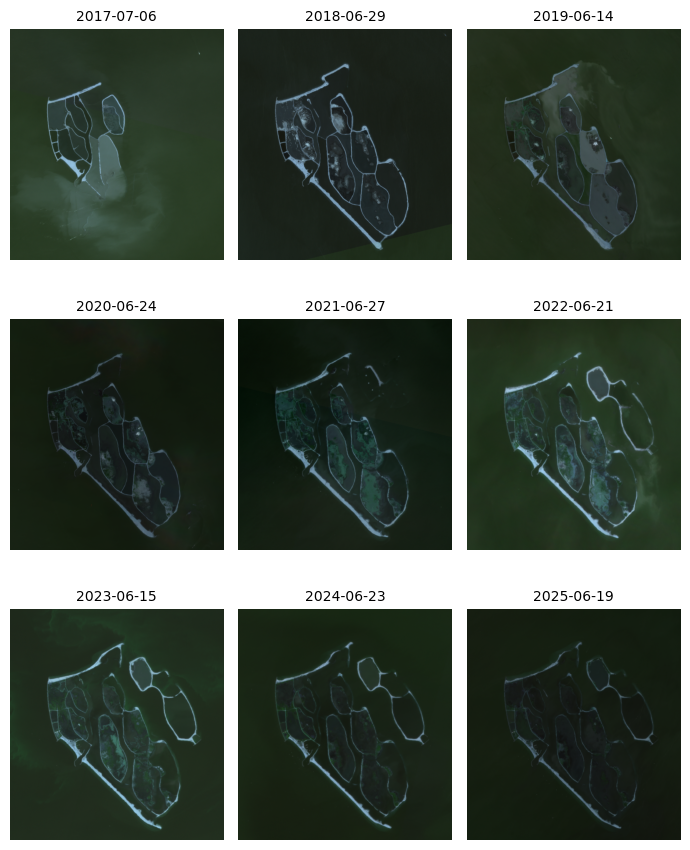

In [10]:
import os
import rasterio
import numpy as np
from rasterio.plot import reshape_as_image

# plot all tif files in summer_months in a subplot of 3x3

import matplotlib.pyplot as plt

n_row = len(summer_months) // 3 + (1 if len(summer_months) % 3 != 0 else 0)
n_col = 3

fig, axes = plt.subplots(n_row, n_col, figsize=(7, 9))
axes = axes.flatten()

for ax, fname in zip(axes, summer_months):
    path = os.path.join(folder, fname)
    try:
        with rasterio.open(path) as src:
            data = src.read()  # (bands, h, w)
            # print shape of data, size in meters, resolution, and available bands
            print(f"File: {fname}")
            print(f"Shape: {data.shape}")
            print(f"Size: {src.width * src.res[0]} x {src.height * src.res[1]} meters")
            print(f"Resolution: {src.res[0]} x {src.res[1]} meters")
            print(f"Bands: {src.count}")

            # use first 3 bands for RGB (pad if fewer bands)
            if data.shape[0] >= 3:
                rgb = data[:3]
            else:
                pad = np.zeros((3 - data.shape[0],) + data.shape[1:], dtype=data.dtype)
                rgb = np.vstack([data, pad])
            img = reshape_as_image(rgb)  # (h, w, 3)
            # normalize for display
            if img.dtype == np.uint8:
                img_disp = img / 255.0
            else:
                vmax = img.max() if img.max() != 0 else 1
                img_disp = img.astype("float32") / vmax
            ax.imshow(img_disp)
            ax.set_title(fname[:10], fontsize=10)
    except Exception:
        ax.text(0.5, 0.5, "Could not open\n" + fname, ha="center", va="center", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [11]:
from scipy.ndimage import convolve

def contrast_stretch_tif(input_path, output_path=None, p_low=2, p_high=98, per_band=True, force_uint8=False):
    """
    Contrast-stretch a GeoTIFF and optionally save result.

    Parameters
    - input_path: path to source tif
    - output_path: path to save result. If None, function returns stretched array (bands, h, w).
      If endswith .png/.jpg/.jpeg the first 3 bands (or padded) are saved as an 8-bit RGB image.
      If endswith .tif the stretched raster is saved with georeference preserved.
    - p_low, p_high: percentiles to use for stretch (per band if per_band=True).
    - per_band: if True compute percentiles per band, otherwise compute across all bands.
    - force_uint8: when writing a GeoTIFF, force output dtype to uint8 (0-255).

    Returns:
    - stretched: numpy array (bands, h, w) with float32 values in [0,1] if output_path is None or for convenience.
    - If output saved, also returns output_path.
    """
    with rasterio.open(input_path) as src:
        meta = src.meta.copy()
        arr = src.read().astype("float32")  # shape (bands, h, w)
        bands, h, w = arr.shape

        # compute percentiles
        if per_band:
            lows = []
            highs = []
            for i in range(bands):
                band = arr[i]
                low, high = np.percentile(band, (p_low, p_high))
                lows.append(float(low))
                highs.append(float(high))
            lows = np.array(lows, dtype="float32")
            highs = np.array(highs, dtype="float32")
        else:
            low, high = np.percentile(arr, (p_low, p_high))
            lows = np.full(bands, float(low), dtype="float32")
            highs = np.full(bands, float(high), dtype="float32")

        # apply stretch per band -> produce float32 [0,1]
        stretched = np.zeros_like(arr, dtype="float32")
        for i in range(bands):
            b = arr[i]
            lo = lows[i]
            hi = highs[i] if highs[i] > lows[i] else (b.max() if b.max() != 0 else 1.0)
            stretched_band = (b - lo) / (hi - lo)
            stretched[i] = np.clip(stretched_band, 0.0, 1.0)
        
        # # sharpen stretch effect using a convolutional sharpening kernel
        # kernel = np.array([[0, -1, 0],
        #            [-1, 5, -1],
        #            [0, -1, 0]], dtype="float32")  # simple 3x3 sharpen
        # for i in range(bands):
        #     stretched[i] = np.clip(convolve(stretched[i], kernel, mode="reflect"), 0.0, 1.0)

    # if no output requested, return stretched (bands, h, w)
    if output_path is None:
        return stretched

    out_lower = output_path.lower()
    # save as image (PNG/JPEG) using first 3 bands, padded if necessary
    if out_lower.endswith((".png", ".jpg", ".jpeg")):
        # prepare HxWx3 image
        if bands >= 3:
            rgb = np.stack([stretched[0], stretched[1], stretched[2]], axis=-1)
        else:
            # pad missing bands with zeros
            pad = np.zeros((h, w, 3 - bands), dtype="float32")
            rgb = np.concatenate([stretched.transpose(1, 2, 0), pad], axis=-1)
        rgb8 = (np.clip(rgb, 0.0, 1.0) * 255).astype("uint8")
        plt.imsave(output_path, rgb8)
        return output_path

    # save as GeoTIFF: convert back to appropriate dtype
    if out_lower.endswith(".tif") or out_lower.endswith(".tiff"):
        dst_meta = meta.copy()
        # choose output dtype
        src_dtype = meta.get("dtype", "uint8")
        if force_uint8:
            dst_dtype = "uint8"
        else:
            # preserve original integer dtype if integer, otherwise use float32
            if np.issubdtype(np.dtype(src_dtype), np.integer):
                dst_dtype = src_dtype
            else:
                dst_dtype = "float32"

        dst_meta.update({
            "dtype": dst_dtype,
            "count": bands
        })

        # scale stretched to destination dtype range
        if np.issubdtype(np.dtype(dst_dtype), np.integer):
            info = np.iinfo(dst_dtype)
            scale_max = info.max
            out_arr = (stretched * scale_max).round().astype(dst_dtype)
        else:
            out_arr = stretched.astype(dst_dtype)

        with rasterio.open(output_path, "w", **dst_meta) as dst:
            dst.write(out_arr)

        return output_path

    # unsupported extension: just return stretched array
    return stretched

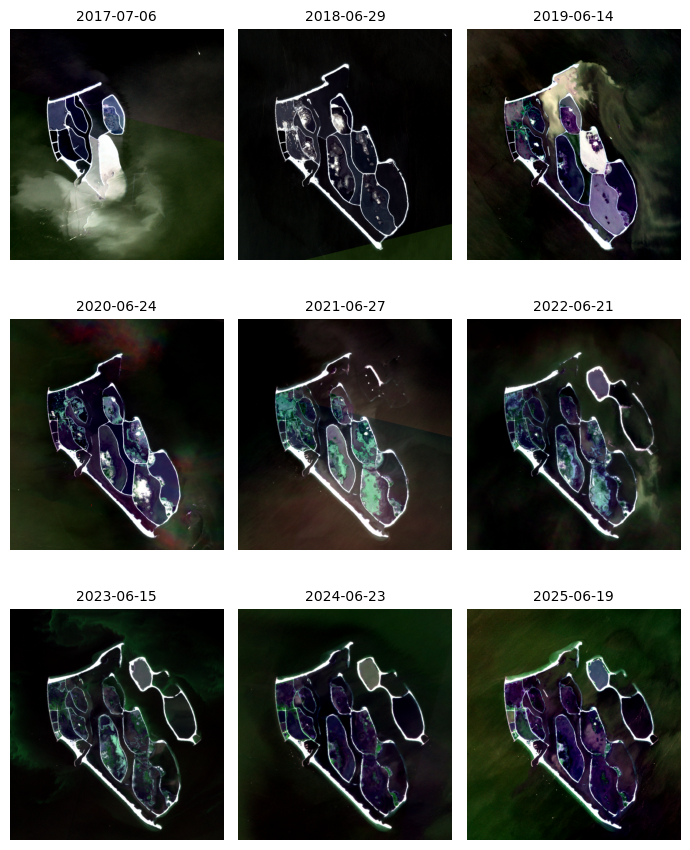

In [12]:
# apply contrast stretch to all summer_months and plot results in a subplot of 3 col x len(summer_months)//3 rows
# create a fresh figure/axes here to avoid showing an empty/other figure
fig, axes = plt.subplots(n_row, n_col, figsize=(7, 9))
axes_arr = axes.flatten()

for ax, fname in zip(axes_arr, summer_months):
    ax.clear()
    path = os.path.join(folder, fname)
    try:
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)  # (bands, h, w) float32 [0,1]
        bands, h, w = stretched.shape

        # prepare HxWx3 image (pad if fewer than 3 bands)
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((h, w, 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        ax.imshow(np.clip(rgb, 0.0, 1.0))
        ax.set_title(fname[:10], fontsize=10)
    except Exception as e:
        ax.text(0.5, 0.5, "Could not open\n" + fname, ha="center", va="center", fontsize=8)
        print(f"Error processing {fname}: {e}")
    ax.axis("off")

# turn off any unused axes
for ax in axes_arr[len(summer_months):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Water occurance probability --> water mask

Processed 2017-07-06_strip_602670_composite.tif: land pixels = 541136
Processed 2018-06-29_strip_1532242_composite.tif: land pixels = 168118
Processed 2019-06-14_strip_2443911_composite.tif: land pixels = 397186
Processed 2020-06-24_strip_3512625_composite.tif: land pixels = 187267
Processed 2021-06-27_strip_4630194_composite.tif: land pixels = 381447
Processed 2022-06-21_strip_5728503_composite.tif: land pixels = 220623
Processed 2023-06-15_strip_6579851_composite.tif: land pixels = 151704
Processed 2024-06-23_strip_7392265_composite.tif: land pixels = 129001
Processed 2025-06-19_strip_8141392_composite.tif: land pixels = 146725


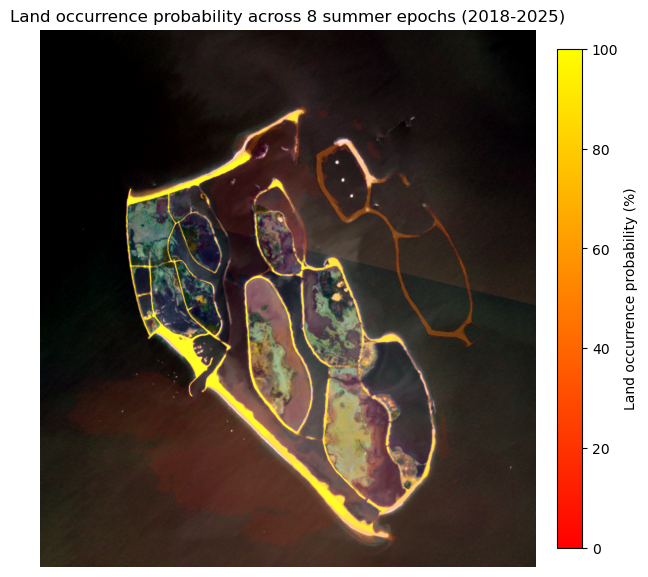

In [40]:
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# Land occurrance probability map
# overlay land areas from all summer epochs into one image
land_count = None
n_epochs = 0

for fname in summer_months:
    path = os.path.join(folder, fname)
    try:
        # get contrast-stretched data and RGB (HxWx3)
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        h, w, _ = rgb.shape
        flat = rgb.reshape(-1, 3)
        # cluster pixels into 2 classes
        km = KMeans(n_clusters=2, random_state=0)
        km.fit(flat)
        labels = km.labels_.reshape(h, w)
        counts = np.bincount(labels.flatten(), minlength=2)
        # assume land is the smaller class (adjust logic if you prefer another heuristic)
        land_label = int(np.argmin(counts))
        land_mask = (labels == land_label).astype("uint8")

        if land_count is None:
            land_count = np.zeros((h, w), dtype="uint16")  # can hold counts up to many epochs
        land_count += land_mask
        n_epochs += 1
        print(f"Processed {fname}: land pixels = {counts[land_label]}")
    except Exception as e:
        print(f"Skipping {fname}: {e}")

if land_count is None:
    raise RuntimeError("No valid images processed.")

# visualize: base = first epoch's stretched RGB (recompute if needed)
base_stretched = contrast_stretch_tif(os.path.join(folder, summer_months[4]), output_path=None, p_low=10, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)

# show base image and overlay heatmap of land frequency
frac = land_count.astype("float32") / float(n_epochs)
land_prob = frac * 100  # percentage
plt.figure(figsize=(7, 7))
plt.imshow(np.clip(base_rgb, 0.0, 1.0))
# overlay red heatmap, alpha proportional to fraction
cax = plt.imshow(land_prob, cmap="autumn", vmin=0, vmax=100, alpha=np.clip(frac * 0.85, 0, 0.85))
plt.title(f"Land occurrence probability across 8 summer epochs (2018-2025)")
plt.axis("off")
cb = plt.colorbar(cax, fraction=0.046, pad=0.04)
cb.set_label("Land occurrence probability (%)")
plt.show()


Processed 2017-07-06_strip_602670_composite.tif: water pixels = 3025188
Processed 2018-06-29_strip_1532242_composite.tif: water pixels = 3398206
Processed 2019-06-14_strip_2443911_composite.tif: water pixels = 3169138
Processed 2020-06-24_strip_3512625_composite.tif: water pixels = 3379057
Processed 2021-06-27_strip_4630194_composite.tif: water pixels = 3184877
Processed 2022-06-21_strip_5728503_composite.tif: water pixels = 3345701
Processed 2023-06-15_strip_6579851_composite.tif: water pixels = 3414620
Processed 2024-06-23_strip_7392265_composite.tif: water pixels = 3437323
Processed 2025-06-19_strip_8141392_composite.tif: water pixels = 3419599


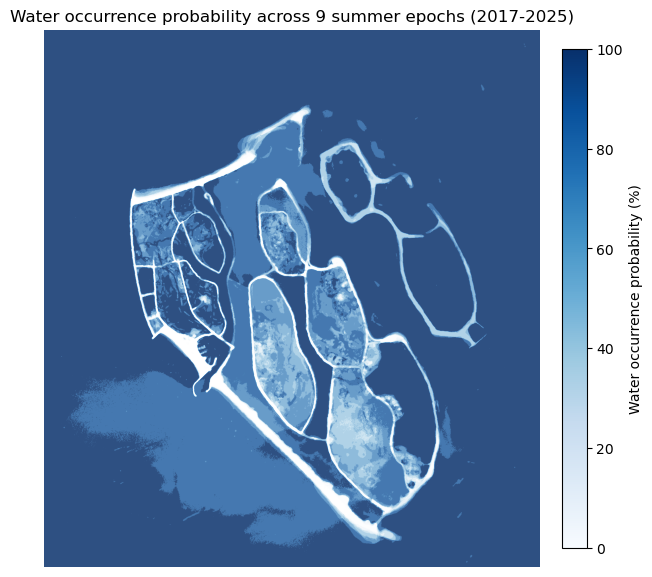

In [41]:
# Water occurrence probability map
# overlay water areas from all summer epochs into one image
water_count = None
n_epochs = 0

for fname in summer_months:
    path = os.path.join(folder, fname)
    try:
        # get contrast-stretched data and RGB (HxWx3)
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        h, w, _ = rgb.shape
        flat = rgb.reshape(-1, 3)
        # cluster pixels into 2 classes
        km = KMeans(n_clusters=2, random_state=0)
        km.fit(flat)
        labels = km.labels_.reshape(h, w)
        counts = np.bincount(labels.flatten(), minlength=2)
        # assume water is the larger class (change from argmin to argmax)
        water_label = int(np.argmax(counts))
        water_mask = (labels == water_label).astype("uint8")

        if water_count is None:
            water_count = np.zeros((h, w), dtype="uint16")
        water_count += water_mask
        n_epochs += 1
        print(f"Processed {fname}: water pixels = {counts[water_label]}")
    except Exception as e:
        print(f"Skipping {fname}: {e}")

if water_count is None:
    raise RuntimeError("No valid images processed.")

# visualize: base = first epoch's stretched RGB (recompute if needed)
base_stretched = contrast_stretch_tif(os.path.join(folder, summer_months[4]), output_path=None, p_low=10, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)

# show base image and overlay heatmap of water frequency
frac = water_count.astype("float32") / float(n_epochs)
water_prob = frac * 100  # percentage
plt.figure(figsize=(7, 7))
# plt.imshow(np.clip(base_rgb, 0.0, 1.0))
# overlay blue heatmap, alpha proportional to fraction (use 'Blues' or 'cool' colormap)
cax = plt.imshow(water_prob, cmap="Blues", vmin=0, vmax=100, alpha=np.clip(frac * 0.85, 0, 0.85))
plt.title(f"Water occurrence probability across {n_epochs} summer epochs (2017-2025)")
plt.axis("off")
cb = plt.colorbar(cax, fraction=0.046, pad=0.04)
cb.set_label("Water occurrence probability (%)")
plt.show()

### Water mask

In [34]:
np.unique(water_prob) # check unique values in water probability map

array([  0.      ,  11.111112,  22.222223,  33.333336,  44.444447,
        55.555557,  66.66667 ,  77.77778 ,  88.88889 , 100.      ],
      dtype=float32)

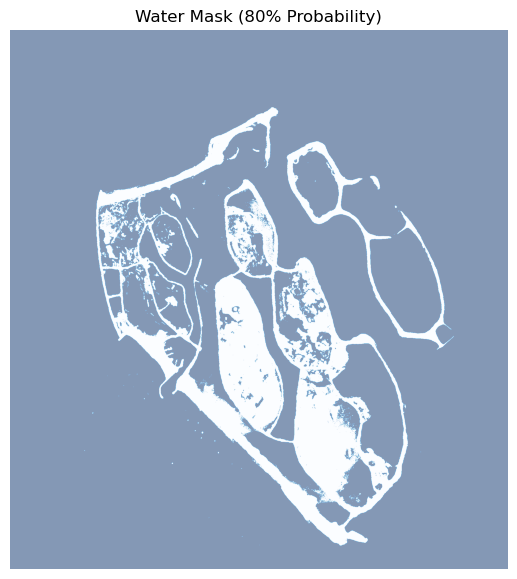

In [46]:
# Create water mask: pixels with water_prob < 10% are considered water (mask=1), else non-water (mask=0)
water_mask = (water_prob > 80).astype("uint8")

# plot water mask
plt.figure(figsize=(7, 7))
plt.imshow(water_mask, cmap="Blues", alpha=0.5)
plt.title("Water Mask (80% Probability)")
plt.axis("off")
plt.show()

In [47]:
water_mask

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)

## K-means

File: 2017-07-06_strip_602670_composite.tif
Unique labels: {0: 3025188, 1: 541136}
Water label: 0, Land label: 1
Water pixels: 3025188, Land pixels: 541136
Unique labels after remap: {0: 215988, 1: 3350336}


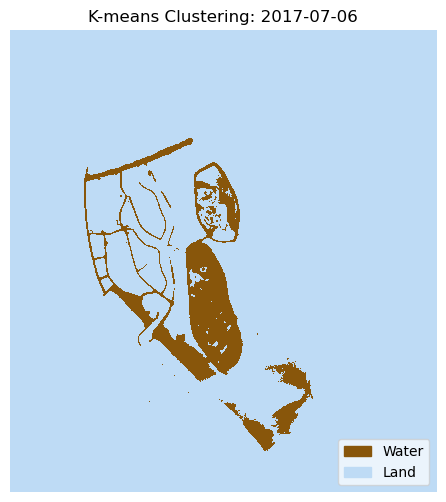

File: 2018-06-29_strip_1532242_composite.tif
Unique labels: {0: 3398206, 1: 168118}
Water label: 0, Land label: 1
Water pixels: 3398206, Land pixels: 168118
Unique labels after remap: {0: 149549, 1: 3416775}


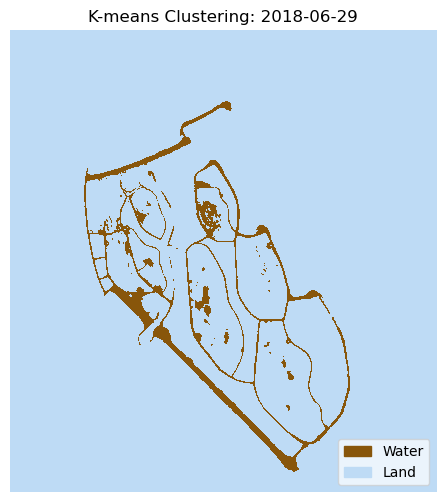

File: 2019-06-14_strip_2443911_composite.tif
Unique labels: {0: 3169138, 1: 397186}
Water label: 0, Land label: 1
Water pixels: 3169138, Land pixels: 397186
Unique labels after remap: {0: 250521, 1: 3315803}


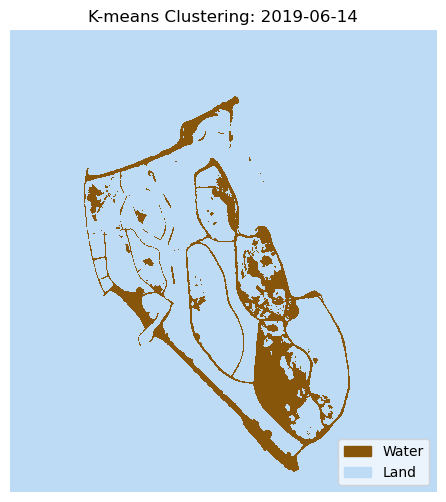

File: 2020-06-24_strip_3512625_composite.tif
Unique labels: {0: 3379057, 1: 187267}
Water label: 0, Land label: 1
Water pixels: 3379057, Land pixels: 187267
Unique labels after remap: {0: 175501, 1: 3390823}


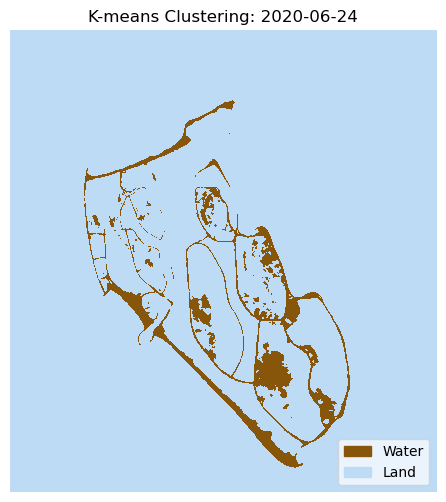

File: 2021-06-27_strip_4630194_composite.tif
Unique labels: {0: 3184877, 1: 381447}
Water label: 0, Land label: 1
Water pixels: 3184877, Land pixels: 381447
Unique labels after remap: {0: 342145, 1: 3224179}


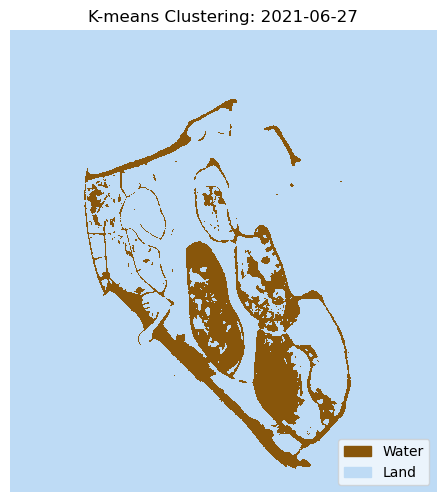

File: 2022-06-21_strip_5728503_composite.tif
Unique labels: {0: 3345701, 1: 220623}
Water label: 0, Land label: 1
Water pixels: 3345701, Land pixels: 220623
Unique labels after remap: {0: 207007, 1: 3359317}


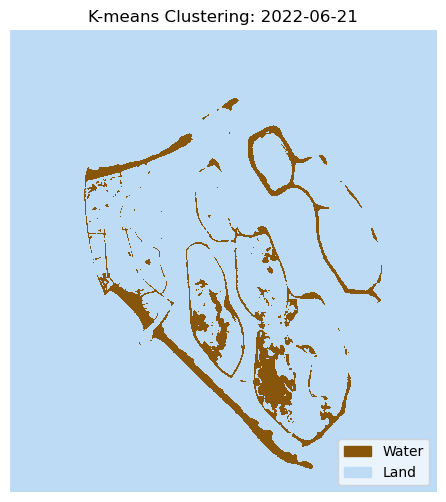

File: 2023-06-15_strip_6579851_composite.tif
Unique labels: {0: 3414620, 1: 151704}
Water label: 0, Land label: 1
Water pixels: 3414620, Land pixels: 151704
Unique labels after remap: {0: 150371, 1: 3415953}


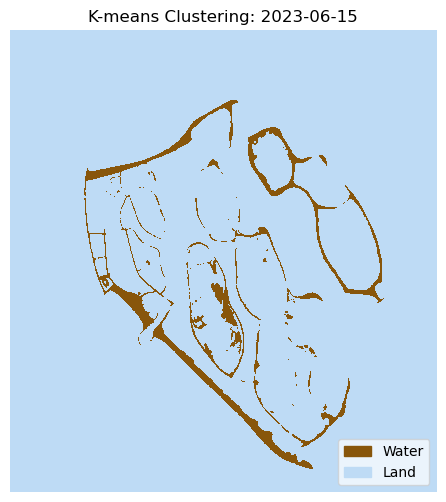

File: 2024-06-23_strip_7392265_composite.tif
Unique labels: {0: 3437323, 1: 129001}
Water label: 0, Land label: 1
Water pixels: 3437323, Land pixels: 129001
Unique labels after remap: {0: 127992, 1: 3438332}


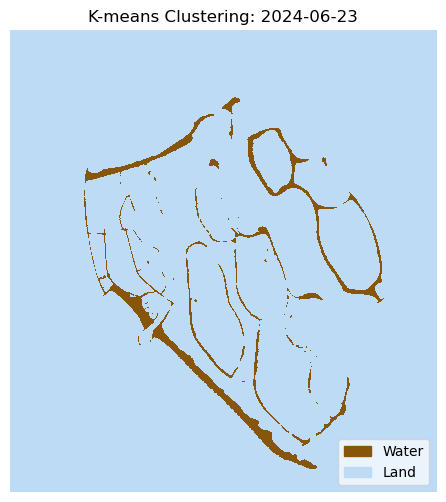

File: 2025-06-19_strip_8141392_composite.tif
Unique labels: {0: 3419599, 1: 146725}
Water label: 0, Land label: 1
Water pixels: 3419599, Land pixels: 146725
Unique labels after remap: {0: 144219, 1: 3422105}


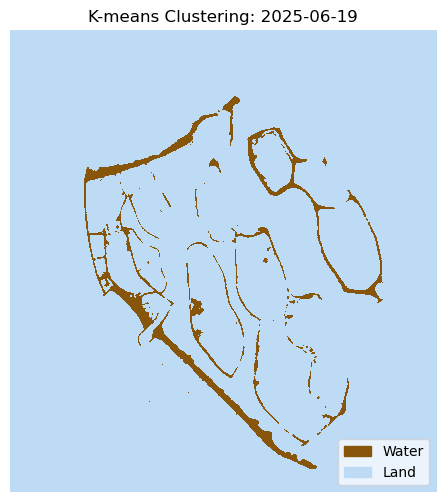

In [52]:
# implement k-means clustering to classify water and land
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

n_clusters = 2  # water and land
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
for fname in summer_months:
    path = os.path.join(folder, fname)
    try:
        with rasterio.open(path) as src:
            data = src.read()  # (bands, h, w)

            # apply contrast stretch for better clustering
            data = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)  # (bands, h, w) float32 [0,1]

            # use first 3 bands for RGB (pad if fewer bands)
            if data.shape[0] >= 3:
                rgb = data[:3]
            else:
                pad = np.zeros((3 - data.shape[0],) + data.shape[1:], dtype=data.dtype)
                rgb = np.vstack([data, pad])
            img = reshape_as_image(rgb)  # (h, w, 3)
            # reshape to (num_pixels, 3)
            h, w, _ = img.shape
            img_reshaped = img.reshape(-1, 3)
            # fit k-means
            kmeans.fit(img_reshaped)
            labels = kmeans.labels_.reshape(h, w)
            # print unique labels found and counts
            unique, counts = np.unique(labels, return_counts=True)
            print(f"File: {fname}")
            print(f"Unique labels: {dict(zip(unique, counts))}")
            # display clustered image
            plt.figure(figsize=(6, 6))

            # determine which cluster is water (more number of cells) and which is land (lower number of cells)

            counts = np.bincount(labels.flatten())
            water_label = int(np.argmax(counts))
            land_label = int(np.argmin(counts))
            print(f"Water label: {water_label}, Land label: {land_label}")
            # print counts of water and land pixels
            print(f"Water pixels: {counts[water_label]}, Land pixels: {counts[land_label]}")

            # Remap labels: water=1, land=0
            labels_remap = np.zeros_like(labels)
            labels_remap[labels == water_label] = 1
            labels_remap[labels == land_label] = 0
            labels = labels_remap

            # apply water_mask to filter out non-water areas
            # note that in water_mask, water=1, non-water=0
            # Retain only water areas within the water_mask boundary
            labels = np.where(water_mask == 0, labels, 1)  # Keep water areas, set others to 0

            # print unique labels found and counts
            unique, counts = np.unique(labels, return_counts=True)
            print(f"Unique labels after remap: {dict(zip(unique, counts))}")

            # assign two colors (water=blue, land=brown)
            colors = ["#BEDBF5" if i == 1 else "#88560b" for i in range(labels.max() + 1)]
            cmap = ListedColormap(colors)
            norm = BoundaryNorm(np.arange(-0.5, n_clusters + 0.5), cmap.N)

            im = plt.imshow(labels, cmap=cmap, norm=norm)
            # add simple legend
            patches = [mpatches.Patch(color=colors[i], label=('Water' if i == water_label else 'Land')) for i in range(n_clusters)]
            plt.legend(handles=patches, loc='lower right', framealpha=0.7)
            plt.title(f"K-means Clustering: {fname[:10]}")
            # add color bar
            # plt.colorbar(ticks=range(n_clusters), label='Cluster Label')
            plt.axis('off')
            plt.show()
    except Exception as e:
        print(f"Error processing {fname}: {e}")
        continue

## Land occurrance probability map (not use in report)

Processed 2017-07-06_strip_602670_composite.tif: land pixels = 541136
Processed 2018-06-29_strip_1532242_composite.tif: land pixels = 168118
Processed 2019-06-14_strip_2443911_composite.tif: land pixels = 397186
Processed 2020-06-24_strip_3512625_composite.tif: land pixels = 187267
Processed 2021-06-27_strip_4630194_composite.tif: land pixels = 381447
Processed 2022-06-21_strip_5728503_composite.tif: land pixels = 220623
Processed 2023-06-15_strip_6579851_composite.tif: land pixels = 151704
Processed 2024-06-23_strip_7392265_composite.tif: land pixels = 129001
Processed 2025-06-19_strip_8141392_composite.tif: land pixels = 146725


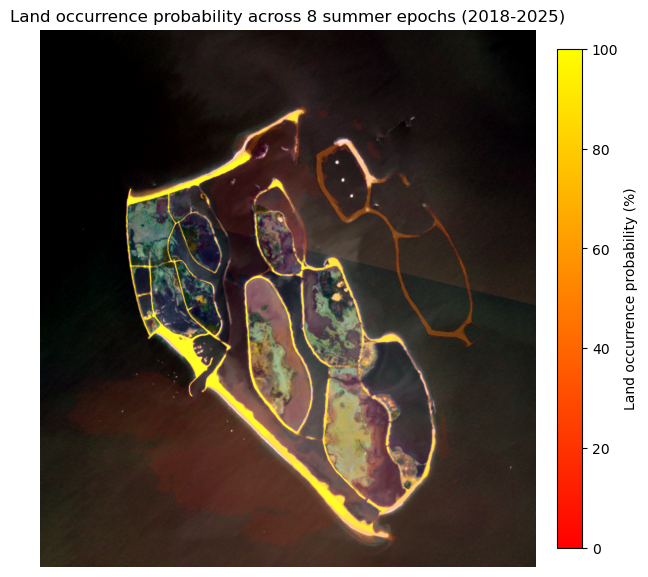

In [14]:
# Land occurrance probability map
# overlay land areas from all summer epochs into one image
land_count = None
n_epochs = 0

for fname in summer_months:
    path = os.path.join(folder, fname)
    try:
        # get contrast-stretched data and RGB (HxWx3)
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        h, w, _ = rgb.shape
        flat = rgb.reshape(-1, 3)
        # cluster pixels into 2 classes
        km = KMeans(n_clusters=2, random_state=0)
        km.fit(flat)
        labels = km.labels_.reshape(h, w)
        counts = np.bincount(labels.flatten(), minlength=2)
        # assume land is the smaller class (adjust logic if you prefer another heuristic)
        land_label = int(np.argmin(counts))
        land_mask = (labels == land_label).astype("uint8")

        if land_count is None:
            land_count = np.zeros((h, w), dtype="uint16")  # can hold counts up to many epochs
        land_count += land_mask
        n_epochs += 1
        print(f"Processed {fname}: land pixels = {counts[land_label]}")
    except Exception as e:
        print(f"Skipping {fname}: {e}")

if land_count is None:
    raise RuntimeError("No valid images processed.")

# visualize: base = first epoch's stretched RGB (recompute if needed)
base_stretched = contrast_stretch_tif(os.path.join(folder, summer_months[4]), output_path=None, p_low=10, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)

# show base image and overlay heatmap of land frequency
frac = land_count.astype("float32") / float(n_epochs)
land_prob = frac * 100  # percentage
plt.figure(figsize=(7, 7))
plt.imshow(np.clip(base_rgb, 0.0, 1.0))
# overlay red heatmap, alpha proportional to fraction
cax = plt.imshow(land_prob, cmap="autumn", vmin=0, vmax=100, alpha=np.clip(frac * 0.85, 0, 0.85))
plt.title(f"Land occurrence probability across 8 summer epochs (2018-2025)")
plt.axis("off")
cb = plt.colorbar(cax, fraction=0.046, pad=0.04)
cb.set_label("Land occurrence probability (%)")
plt.show()


## Coastline extraction & contour plots

In [15]:
# extract coastlines from k-means results (after remapping) and smooth them
from scipy.ndimage import binary_erosion
from rasterio.features import shapes
from shapely.geometry import shape, mapping
import json

def chaikin_smooth_coords(coords, iterations=2, closed=False):
    """
    Chaikin subdivision smoothing for a list of (x,y) coords.
    closed=True treats the polyline as a closed loop.
    """
    if len(coords) < 2:
        return coords
    pts = list(coords)
    for _ in range(iterations):
        new_pts = []
        if closed:
            n = len(pts)
            for i in range(n):
                p0 = np.array(pts[i])
                p1 = np.array(pts[(i + 1) % n])
                q = 0.75 * p0 + 0.25 * p1
                r = 0.25 * p0 + 0.75 * p1
                new_pts.append(tuple(q))
                new_pts.append(tuple(r))
            pts = new_pts
        else:
            # open polyline: keep endpoints, smooth interior
            new_pts.append(pts[0])
            for i in range(len(pts) - 1):
                p0 = np.array(pts[i])
                p1 = np.array(pts[i + 1])
                q = 0.75 * p0 + 0.25 * p1
                r = 0.25 * p0 + 0.75 * p1
                new_pts.append(tuple(q))
                new_pts.append(tuple(r))
            new_pts.append(pts[-1])
            pts = new_pts
    return pts

def smooth_shapely_geom(shp, iterations=2):
    """
    Smooth LineString / MultiLineString geometries using Chaikin smoothing.
    Returns a shapely geometry of the same top-level type (LineString or MultiLineString).
    """
    from shapely.geometry import LineString, MultiLineString
    if shp.is_empty:
        return shp
    if shp.geom_type == "LineString":
        coords = list(shp.coords)
        closed = (coords[0] == coords[-1])
        if len(coords) <= 3:
            return shp  # too short to meaningfully smooth
        new_coords = chaikin_smooth_coords(coords, iterations=iterations, closed=closed)
        # ensure we keep a valid LineString (at least 2 points)
        return LineString(new_coords) if len(new_coords) >= 2 else shp
    elif shp.geom_type == "MultiLineString":
        parts = []
        for part in shp.geoms:
            s = smooth_shapely_geom(part, iterations=iterations)
            if not s.is_empty:
                parts.append(s)
        return MultiLineString(parts) if parts else shp
    else:
        return shp  # don't alter non-line geometries here

coastlines = {}  # fname -> list of GeoJSON-like geometries (LineString / MultiLineString)
for fname in summer_months:
    path = os.path.join(folder, fname)
    try:
        with rasterio.open(path) as src:
            # get contrast-stretched RGB (HxWx3)
            stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
            if stretched.shape[0] >= 3:
                rgb = stretched[:3].transpose(1, 2, 0)
            else:
                rgb = stretched.transpose(1, 2, 0)
                pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
                rgb = np.concatenate([rgb, pad], axis=2)

            h, w, _ = rgb.shape
            flat = rgb.reshape(-1, 3)

            # cluster into 2 classes and remap as before (land_label = smaller class)
            km = KMeans(n_clusters=2, random_state=0).fit(flat)
            labels = km.labels_.reshape(h, w)
            counts = np.bincount(labels.flatten(), minlength=2)
            land_label = int(np.argmin(counts))
            land_mask = (labels == land_label)

            # get 1-px wide land-edge (boundary of land regions)
            eroded = binary_erosion(land_mask, structure=np.ones((3, 3)))
            land_boundary_mask = land_mask & (~eroded)

            # Vectorize land polygons then extract polygon boundaries (preferred)
            geom_lines = []
            for geom, val in shapes(land_mask.astype("uint8"), mask=None, transform=src.transform):
                if int(val) == 1:
                    poly = shape(geom)
                    boundary = poly.boundary
                    if not boundary.is_empty:
                        smooth_b = smooth_shapely_geom(boundary, iterations=5)
                        geom_lines.append(mapping(smooth_b))

            # fallback: if no polygons produced, vectorize pixel-boundary mask directly
            if not geom_lines:
                for geom, val in shapes(land_boundary_mask.astype("uint8"), mask=None, transform=src.transform):
                    if int(val) == 1:
                        shp = shape(geom) if not hasattr(geom, "geom_type") else geom
                        smooth_shp = smooth_shapely_geom(shp, iterations=2) if hasattr(shp, "geom_type") else shp
                        geom_lines.append(mapping(smooth_shp))

            coastlines[fname] = geom_lines

            # save per-file GeoJSON of coastlines
            features = [{"type": "Feature", "properties": {"source": fname}, "geometry": g} for g in geom_lines]
            out_geojson = os.path.join(folder, fname.replace(".tif", "_coastlines.geojson"))
            with open(out_geojson, "w") as fh:
                json.dump({"type": "FeatureCollection", "features": features}, fh)

            print(f"{fname}: extracted {len(geom_lines)} (smoothed) coastline geometries -> {out_geojson}")
    except Exception as e:
        print(f"Skipping {fname}: {e}")

# coastlines dict now contains smoothed geometries for plotting/analysis


2017-07-06_strip_602670_composite.tif: extracted 1842 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2017-07-06_strip_602670_composite_coastlines.geojson
2018-06-29_strip_1532242_composite.tif: extracted 158 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2018-06-29_strip_1532242_composite_coastlines.geojson
2019-06-14_strip_2443911_composite.tif: extracted 371 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2019-06-14_strip_2443911_composite_coastlines.geojson
2020-06-24_strip_3512625_composite.tif: extracted 358 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2020-06-24_strip_3512625_composite_coastlines.geojson
2021-06-27_strip_4630194_composite.tif: extracted 679 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2021-06-27_strip_4630194_composite_coastlines.geojson
2022-06-21_strip_5728503_composite.tif: extracted 417 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2022-06-21_strip_5728503_composite_

C:\Users\Move\AppData\Local\Temp\ipykernel_12228\2154929916.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10" if n <= 10 else "tab20")
C:\Users\Move\AppData\Local\Temp\ipykernel_12228\2154929916.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{float(x):.0f}" for x in xtick_world], rotation=45)
C:\Users\Move\AppData\Local\Temp\ipykernel_12228\2154929916.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{float(y):.0f}" for y in ytick_world])


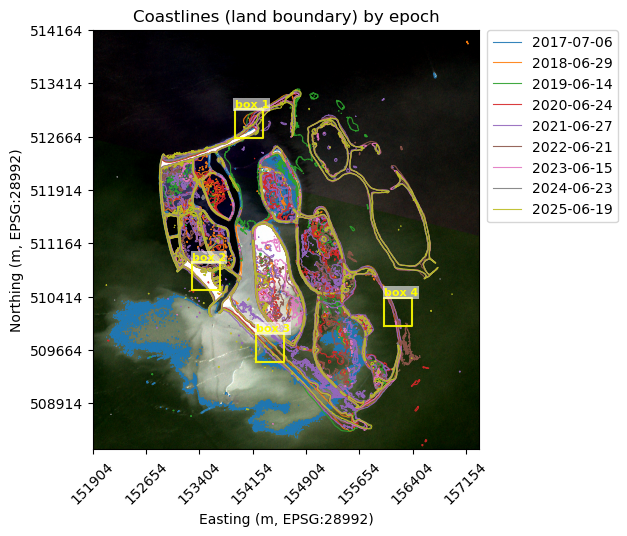

In [16]:
# plot extracted coastlines over base image (one color per epoch, legend with year)
import matplotlib.pyplot as plt
from shapely.geometry import shape as geom_shape
import matplotlib.cm as cm
import rasterio

# use the first summer month as reference for transform and base image
ref_path = os.path.join(folder, summer_months[0])
with rasterio.open(ref_path) as ref_ds:
    ref_transform = ref_ds.transform

# compute base_rgb from the same reference file (first summer epoch)
base_stretched = contrast_stretch_tif(os.path.join(folder, summer_months[0]), output_path=None, p_low=15, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)

# prepare colors (one per summer epoch)
n = len(summer_months)
palette = cm.get_cmap("tab10" if n <= 10 else "tab20")
colors = [palette(i % palette.N) for i in range(n)]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# show base image; ensure origin='upper' so pixel coords align with row indices
ax.imshow(np.clip(base_rgb, 0.0, 1.0), origin="upper", aspect="equal")

# plot coastlines year-by-year with one legend entry per year
added_labels = set()
for i, fname in enumerate(summer_months):
    geom_list = coastlines.get(fname)
    if not geom_list:
        continue
    color = colors[i]
    label = fname[:10]  # YYYY-MM-DD
    first_plotted = False
    for geom in geom_list:
        # geom may already be a mapping (dict) or shapely-like; convert to shapely
        shp = geom_shape(geom) if not hasattr(geom, "geom_type") else geom
        # handle LineString and MultiLineString uniformly
        if shp.is_empty:
            continue
        if shp.geom_type == "LineString":
            lines = [shp]
        elif shp.geom_type == "MultiLineString":
            lines = list(shp.geoms)
        else:
            # skip non-line geometries
            continue

        for line in lines:
            coords = list(line.coords)
            if not coords:
                continue
            # convert world coords (x,y) -> pixel coords (col, row) using inverse transform
            inv = ~ref_transform
            pix = [inv * (x, y) for (x, y) in coords]  # list of (col, row)
            cols, rows = zip(*pix)
            # plot; add label only once per file to avoid duplicates in legend
            if (label not in added_labels) and (not first_plotted):
                ax.plot(cols, rows, color=color, linewidth=0.8, alpha=0.9, label=label)
                added_labels.add(label)
                first_plotted = True
            else:
                ax.plot(cols, rows, color=color, linewidth=0.8, alpha=0.9)

# finalize
ax.set_title("Coastlines (land boundary) by epoch")
# convert pixels to world coordinates for axis ticks
xticks = ax.get_xticks()
yticks = ax.get_yticks()
# ensure we transform each tick as a coordinate tuple, then pick the relevant component
xtick_world = [ (ref_transform * (x, 0))[0] for x in xticks ]
ytick_world = [ (ref_transform * (0, y))[1] for y in yticks ]
ax.set_xticklabels([f"{float(x):.0f}" for x in xtick_world], rotation=45)
ax.set_yticklabels([f"{float(y):.0f}" for y in ytick_world])
ax.set_xlabel("Easting (m, EPSG:28992)")
ax.set_ylabel("Northing (m, EPSG:28992)")
ax.axis("on")

# draw requested world-aligned boxes (convert world -> pixel using inverse transform)
boxes = [
    (153900, 512650, 153900+400, 512650+400),
    (153300, 510500, 153300+400, 510500+400),
    (154200, 509500, 154200+400, 509500+400),
    (156000, 510000, 156000+400, 510000+400),
]

inv = ~ref_transform
box_color = "yellow"

for idx, (bx_minx, bx_miny, bx_maxx, bx_maxy) in enumerate(boxes):
    # build world coords for box corners (closed polygon)
    world_corners = [
        (bx_minx, bx_miny),
        (bx_minx, bx_maxy),
        (bx_maxx, bx_maxy),
        (bx_maxx, bx_miny),
        (bx_minx, bx_miny),
    ]
    pix = [inv * (x, y) for (x, y) in world_corners]  # (col, row)
    cols, rows = zip(*pix)
    ax.plot(cols, rows, color=box_color, linewidth=1.5, alpha=0.9)
    # label as "box <n>" near the top-left corner
    ax.text(cols[1], rows[1] - 8, f"box {idx+1}", color=box_color, fontsize=8, weight="bold",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1))

# place legend outside the plot
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()


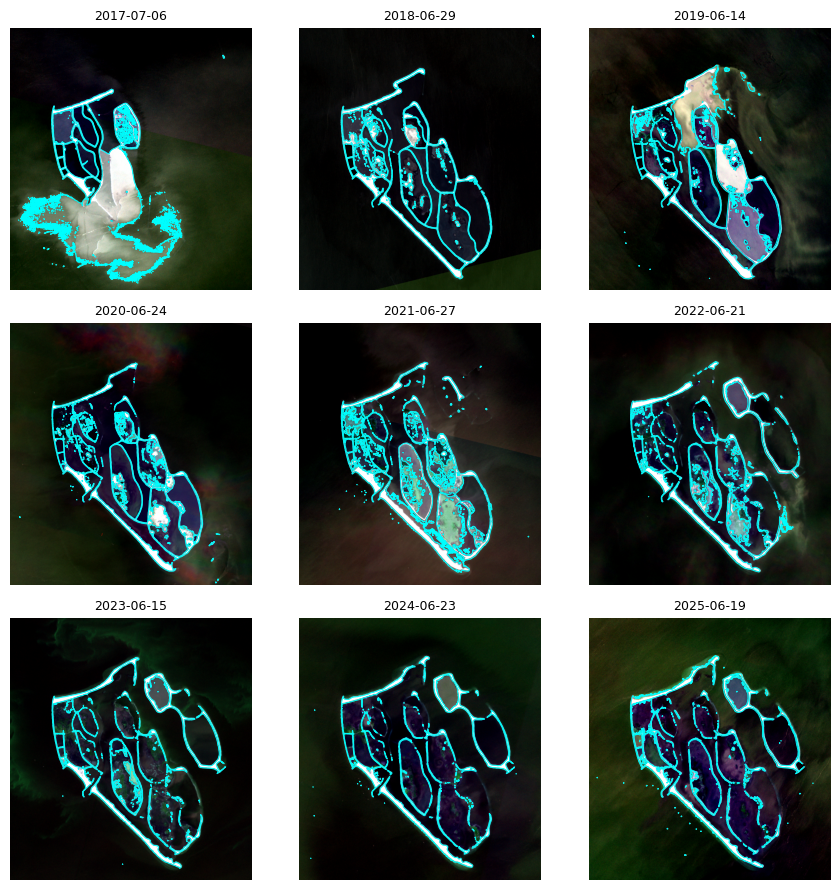

In [17]:
# subplot coastline overlay for all summer months (3 columns)
ncols = 3
n = len(summer_months)
nrows = n // ncols + (1 if n % ncols else 0)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for ax, fname in zip(axes, summer_months):
    path = os.path.join(folder, fname)
    try:
        # read transform for this raster (used to convert world->pixel)
        with rasterio.open(path) as ds:
            transform = ds.transform

        # get contrast-stretched RGB for this file
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        ax.imshow(np.clip(rgb, 0.0, 1.0), origin="upper", aspect="equal")

        geom_list = coastlines.get(fname, [])
        if geom_list:
            inv = ~transform
            for geom in geom_list:
                shp = geom_shape(geom) if not hasattr(geom, "geom_type") else geom
                if shp.is_empty:
                    continue
                # normalize to line(s)
                if shp.geom_type == "LineString":
                    lines = [shp]
                elif shp.geom_type == "MultiLineString":
                    lines = list(shp.geoms)
                else:
                    lines = [g for g in getattr(shp, "geoms", []) if g.geom_type == "LineString"]
                for line in lines:
                    coords = list(line.coords)
                    if not coords:
                        continue
                    pix = [inv * (x, y) for (x, y) in coords]  # (col, row)
                    cols, rows = zip(*pix)
                    ax.plot(cols, rows, color="cyan", linewidth=0.8, alpha=0.9)

        ax.set_title(fname[:10], fontsize=9)
        ax.axis("off")
    except Exception as e:
        ax.clear()
        ax.text(0.5, 0.5, f"Error\n{fname[:10]}\n{e}", ha="center", va="center", fontsize=8)
        ax.axis("off")

# turn off any remaining empty axes
for ax in axes[len(summer_months):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


Image size: 1814 1966
Crop window: 665 799 371 505
Bbox: 153900 512650 154300 513050


C:\Users\Move\AppData\Local\Temp\ipykernel_12228\2723337141.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10" if n <= 10 else "tab20")


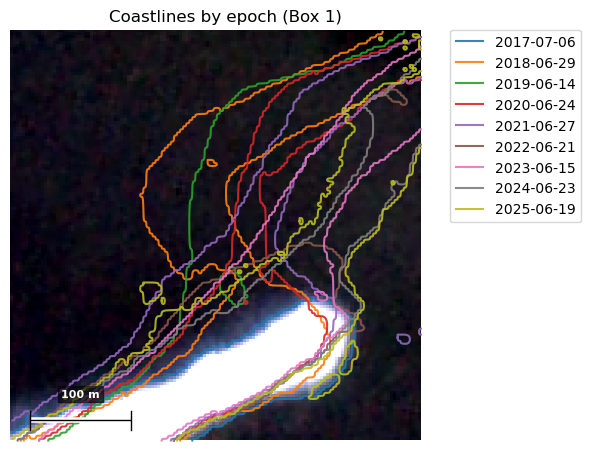

In [20]:
from shapely.geometry import box

# plot extracted coastlines over base image, cropped to bbox (world coords)
# minx, miny, maxx, maxy = 661180, 5827300, 661180+350, 5827300+350
# minx, miny, maxx, maxy = 155000, 508500, 155500, 509000

box_no = 0  # change to select a different box
minx, miny, maxx, maxy = boxes[box_no]  # use first box as example

# use the first summer month as reference for transform and base image
ref_path = os.path.join(folder, summer_months[0])
with rasterio.open(ref_path) as ref_ds:
    ref_transform = ref_ds.transform

# inverse transform: world -> pixel (col, row)
inv = ~ref_transform

# map bbox corners to pixel coords and build integer window (clamped to image)
tl = inv * (minx, maxy)  # top-left world -> pixel (col, row)
br = inv * (maxx, miny)  # bottom-right world -> pixel (col, row)

# get float bounds then integer window
col_min_f = min(tl[0], br[0])
col_max_f = max(tl[0], br[0])
row_min_f = min(tl[1], br[1])
row_max_f = max(tl[1], br[1])

col0 = int(np.floor(col_min_f))
row0 = int(np.floor(row_min_f))
col1 = int(np.ceil(col_max_f))
row1 = int(np.ceil(row_max_f))

# clamp to image bounds (ensure values stay within [0, w] and [0, h])
col0 = max(0, min(w, col0))
col1 = max(0, min(w, col1))
row0 = max(0, min(h, row0))
row1 = max(0, min(h, row1))

print("Image size:", w, h)
print("Crop window:", col0, col1, row0, row1)
print("Bbox:", minx, miny, maxx, maxy)

# if the window is empty after clamping, the bbox doesn't intersect the image
if col1 <= col0 or row1 <= row0:
    raise RuntimeError("Computed crop window is empty (bbox may lie outside the image).")

# crop base image (pixel coordinates: rows, cols)
base_rgb_crop = base_rgb[row0:row1, col0:col1].copy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(np.clip(base_rgb_crop, 0.0, 1.0), origin="upper", aspect="equal")

# build bbox polygon once (world coordinates)
bbox_geom = box(minx, miny, maxx, maxy)

# plot coastlines clipped/translated into cropped pixel coordinates
legend_added = set()
n = len(summer_months)
palette = cm.get_cmap("tab10" if n <= 10 else "tab20")
colors_local = [palette(i % palette.N) for i in range(n)]

for i, fname in enumerate(summer_months):
    geom_list = coastlines.get(fname)
    if not geom_list:
        continue
    color = colors_local[i]
    label = fname[:10]

    for geom in geom_list:
        shp = geom_shape(geom) if not hasattr(geom, "geom_type") else geom
        if shp.is_empty:
            continue

        # quick bbox reject (optional; keeps performance)
        gb = shp.bounds  # (xmin, ymin, xmax, ymax)
        if (gb[2] < minx) or (gb[0] > maxx) or (gb[3] < miny) or (gb[1] > maxy):
            continue

        # clip to bbox so we only plot segments inside the bbox
        clipped = shp.intersection(bbox_geom)
        if clipped.is_empty:
            continue

        # normalize to a list of LineString segments
        lines = []
        if clipped.geom_type == "LineString":
            lines = [clipped]
        elif clipped.geom_type == "MultiLineString":
            lines = list(clipped.geoms)
        else:  # handle GeometryCollection that may contain lines
            for g in getattr(clipped, "geoms", []):
                if g.geom_type == "LineString":
                    lines.append(g)
                elif g.geom_type == "MultiLineString":
                    lines.extend(list(g.geoms))

        if not lines:
            continue

        first_plotted = False
        for line in lines:
            coords = list(line.coords)
            if not coords:
                continue
            # convert world coords to original pixel coords then to cropped pixel coords
            pix = [inv * (x, y) for (x, y) in coords]  # (col, row)
            cols, rows = zip(*pix)
            cols_local = np.array(cols) - col0
            rows_local = np.array(rows) - row0
            if (label not in legend_added) and (not first_plotted):
                ax.plot(cols_local, rows_local, color=color, linewidth=1.5, alpha=0.9, label=label)
                legend_added.add(label)
                first_plotted = True
            else:
                ax.plot(cols_local, rows_local, color=color, linewidth=1.5, alpha=0.9)

# finalize (with scalebar)
ax.set_title(f"Coastlines by epoch (Box {box_no + 1})")

# draw scale bar (meters)
import math
# approximate meters-per-pixel (handles typical north-up and handles signed pixel height)
mpp_x = abs(ref_transform.a)
mpp_y = abs(ref_transform.e)
mpp = (mpp_x + mpp_y) / 2.0 if (mpp_x > 0 and mpp_y > 0) else (mpp_x or mpp_y)

# world width of crop (meters) -> choose a "nice" scale length <= 1/4 width
world_width = maxx - minx
candidates = [5000,2000,1000,500, 200, 100, 50, 20, 10, 5, 2, 1]  # in meters
scale_len_m = next((c for c in candidates if c <= (world_width / 4.0)), candidates[-1])

# pixel length of scale bar in the cropped image
ncols_crop = base_rgb_crop.shape[1]
nrows_crop = base_rgb_crop.shape[0]
px_len = max(1, int(round(scale_len_m / mpp)))

# position: 5% from left, 5% from bottom (origin='upper' so bottom ~ high row index)
x0 = int(ncols_crop * 0.05)
y0 = int(nrows_crop * 0.95)

# draw white bar with black edge for visibility
ax.plot([x0, x0 + px_len], [y0, y0], color='white', linewidth=4, solid_capstyle='butt', zorder=20)
ax.plot([x0, x0 + px_len], [y0, y0], color='black', linewidth=1, solid_capstyle='butt', zorder=21)

# small end ticks
tick_h = max(3, int(nrows_crop * 0.01))
ax.plot([x0, x0], [y0 - tick_h, y0 + tick_h], color='black', linewidth=1, zorder=21)
ax.plot([x0 + px_len, x0 + px_len], [y0 - tick_h, y0 + tick_h], color='black', linewidth=1, zorder=21)

# label centered above the bar
ax.text(x0 + px_len / 2.0, y0 - tick_h - 4, f"{scale_len_m} m",
        color='white', ha='center', va='bottom', fontsize=8, weight='bold',
        bbox=dict(facecolor='black', alpha=0.6, pad=2), zorder=22)

ax.axis("off")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()


In [19]:
# print crs of reference image
with rasterio.open(ref_path) as ref_ds:
    print("Reference image CRS:", ref_ds.crs)

Reference image CRS: EPSG:28992
